<a href="https://colab.research.google.com/github/Prathibha-bm/CD040/blob/main/ML_Project_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Machine Learning Task: Customer Churn Prediction (Classification)**

Customer churn is a major concern for businesses, especially in industries like telecom, banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.

In this project, the goal is to build a Machine Learning classification model that predicts whether a customer will leave the company (Churn: Yes/No) based on features such as:

● Customer Age

● Gender

● Tenure

● Monthly Charges

● Total Charges

● Contract Type

● Payment Method

● Internet Service

● Tech Support

● Online Security

● Customer Support Calls


#Objective


The objective of this task is to:

● Understand and explore the customer dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model


#1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. Load the Dataset

In [ ]:
df=pd.read_csv("/content/telecom_churn_data (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


#3. Check Dataset

● Shape

● Columns

● Data types

● Summary statistics

In [ ]:
#shape
print("Shape:", df.shape)

Shape: (7043, 21)


In [ ]:
#columns
print("\nColumns:\n", df.columns)


Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
#Datatypes
print("\nData Types:\n", df.dtypes)


Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
#summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 4.Handle Missing Values

In [ ]:
print(df.isnull().sum())

customerID          0
gender              5
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    2
PaymentMethod       0
MonthlyCharges      2
TotalCharges        5
Churn               0
dtype: int64


# 5. Remove Duplicate Records

In [ ]:
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

After removing duplicates: (7043, 21)


# 6. Perform Univariate Analysis

● Distribution of numerical features

● Count plots for categorical features

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

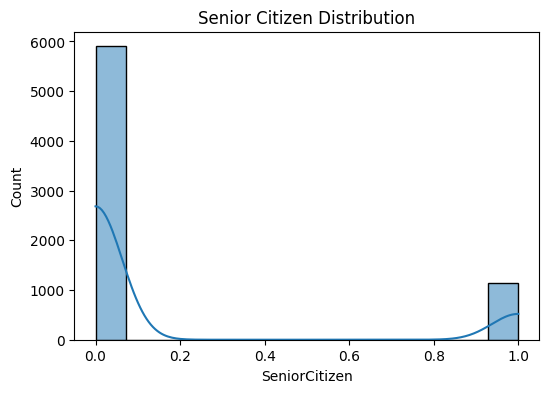

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['SeniorCitizen'], kde=True)
plt.title("Senior Citizen Distribution")
plt.show()

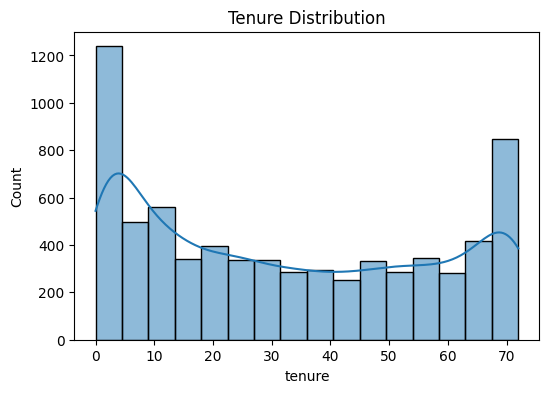

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

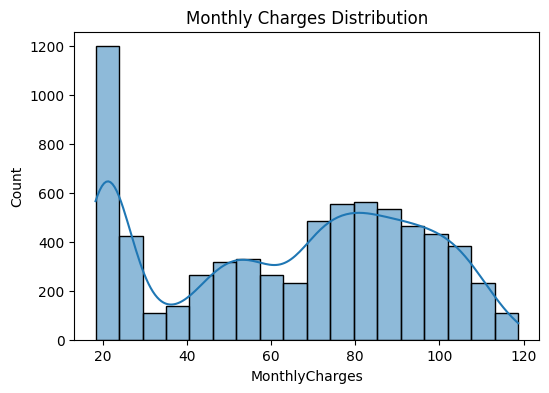

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

#Categorical Features (Count Plot)

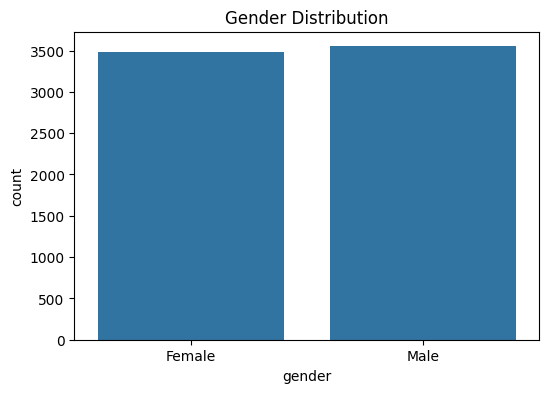

In [ ]:
#Distribution Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['gender'])
plt.title("Gender Distribution")
plt.show()

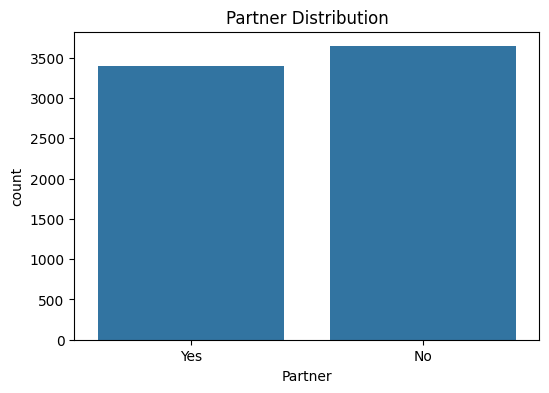

In [ ]:
#Partner Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['Partner'])
plt.title("Partner Distribution")
plt.show()

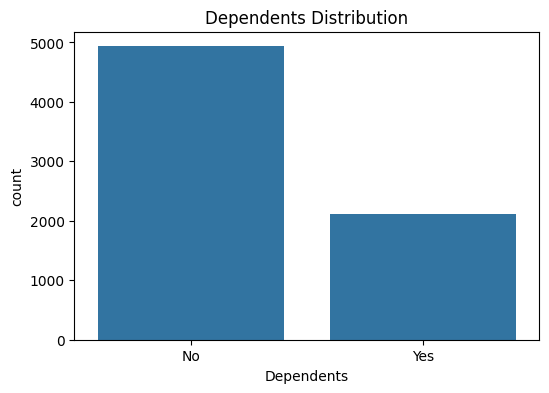

In [ ]:
#Distribution of Dependents Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['Dependents'])
plt.title("Dependents Distribution")
plt.show()

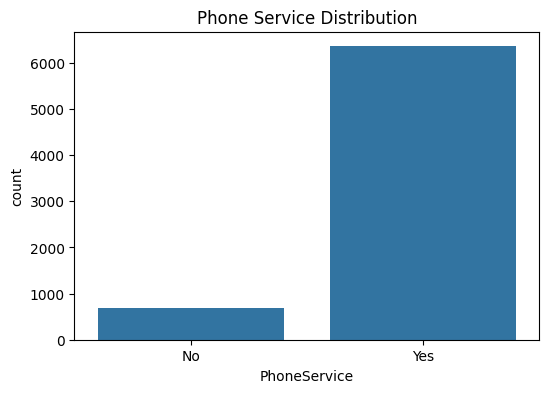

In [ ]:
#Distribution of Phone Service Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['PhoneService'])
plt.title("Phone Service Distribution")
plt.show()

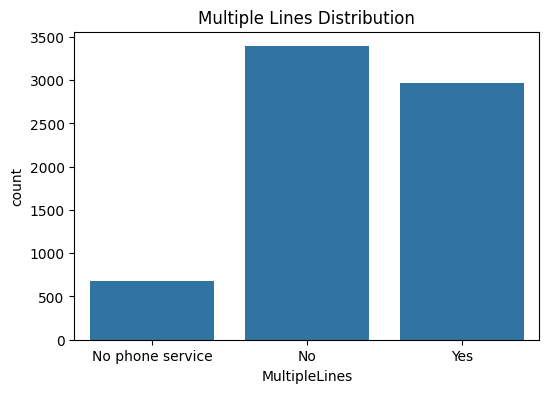

In [ ]:
#Distribution pf Multiple Lines Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['MultipleLines'])
plt.title("Multiple Lines Distribution")
plt.show()

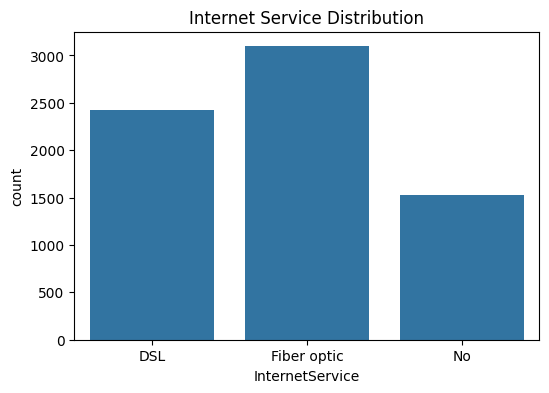

In [ ]:
#Distribution of Internet Service Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['InternetService'])
plt.title("Internet Service Distribution")
plt.show()

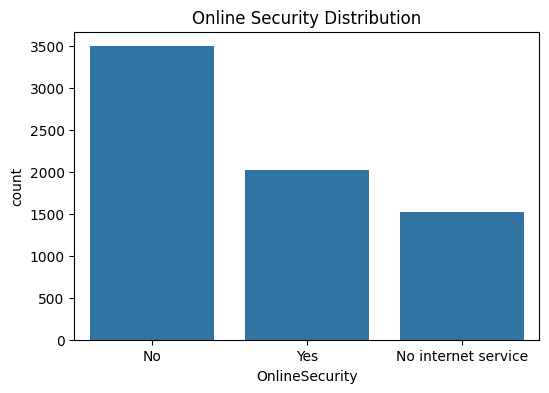

In [ ]:
#Distribution of Online Security Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['OnlineSecurity'])
plt.title("Online Security Distribution")
plt.show()

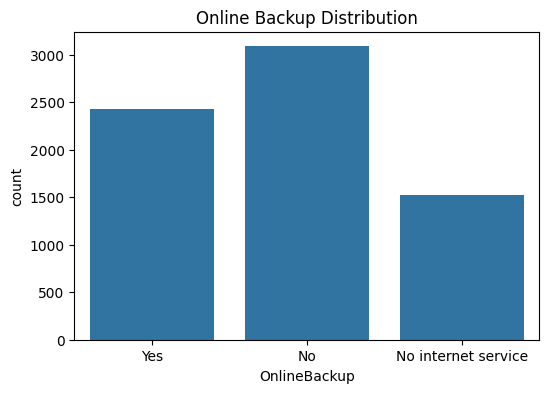

In [ ]:
#Distribution of Online Backup Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['OnlineBackup'])
plt.title("Online Backup Distribution")
plt.show()

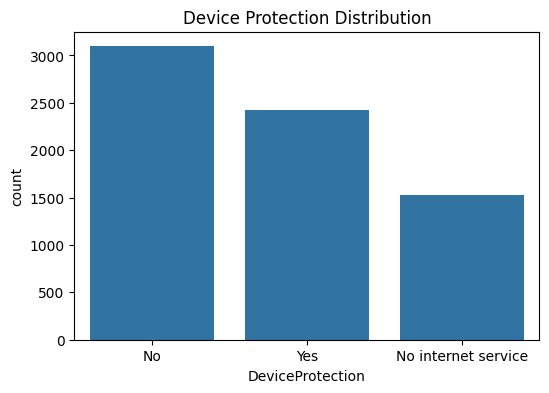

In [ ]:
#Distribution ofDevice Protection Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['DeviceProtection'])
plt.title("Device Protection Distribution")
plt.show()

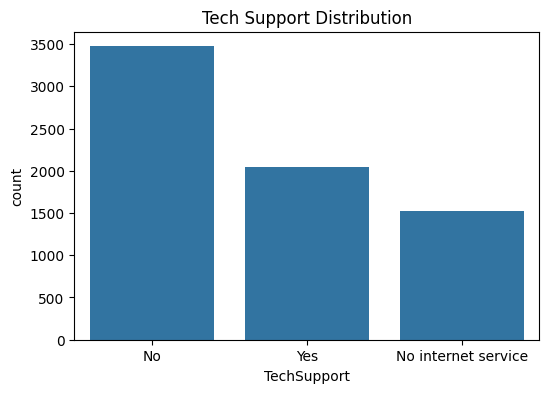

In [ ]:
#Distribution of Tech Support Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['TechSupport'])
plt.title("Tech Support Distribution")
plt.show()

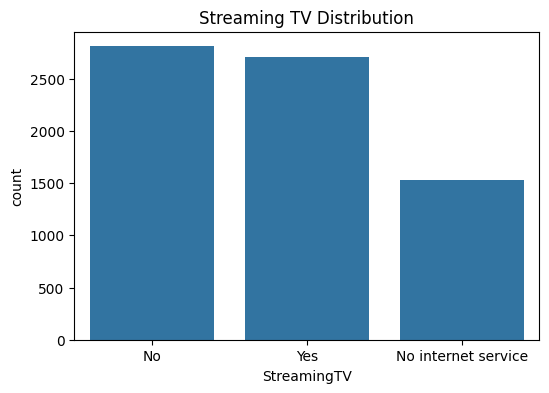

In [ ]:
#Distribution of Streaming TV Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['StreamingTV'])
plt.title("Streaming TV Distribution")
plt.show()

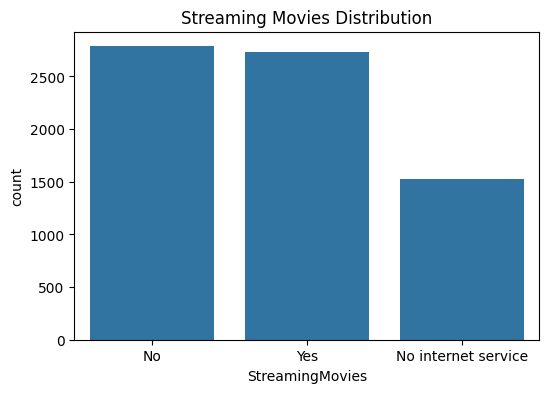

In [ ]:
#Distribution of Streaming Movies Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['StreamingMovies'])
plt.title("Streaming Movies Distribution")
plt.show()

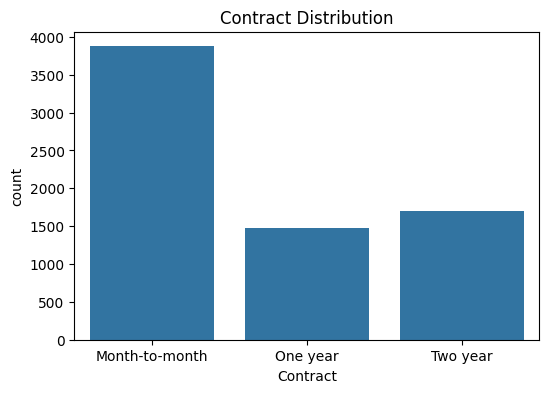

In [ ]:
#distribution of Contract Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['Contract'])
plt.title("Contract Distribution")
plt.show()

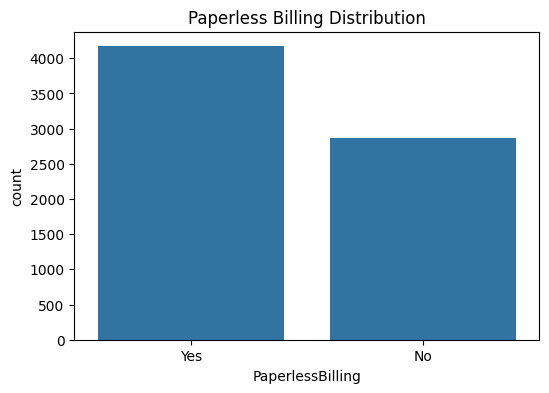

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['PaperlessBilling'])
plt.title("Paperless Billing Distribution")
plt.show()

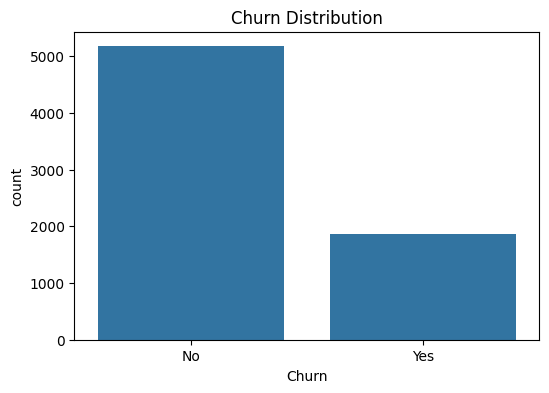

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Churn'])
plt.title("Churn Distribution")
plt.show()

# 7. Perform Bivariate Analysis

● Attrition vs categorical features

● Attrition vs numerical features

#Churn vs Numerical Features

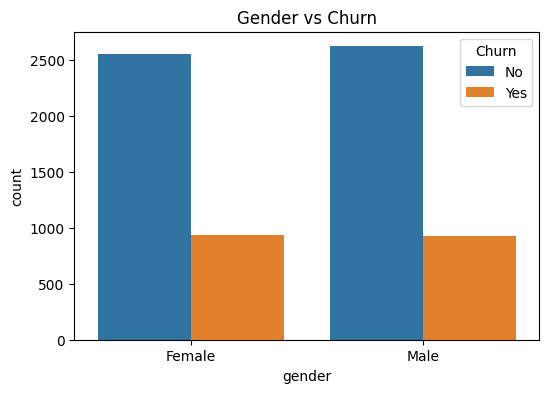

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

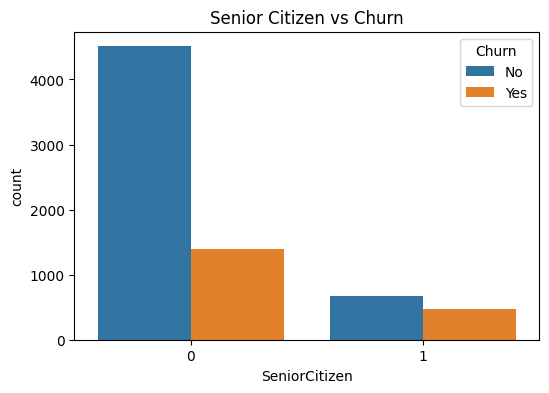

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

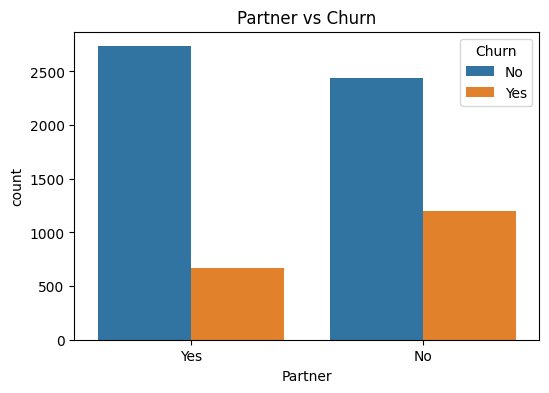

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Partner vs Churn")
plt.show()

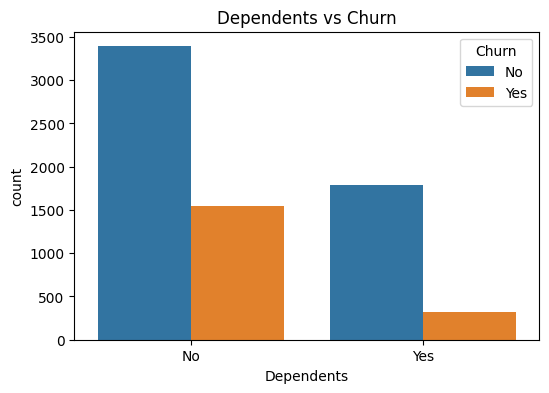

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title("Dependents vs Churn")
plt.show()

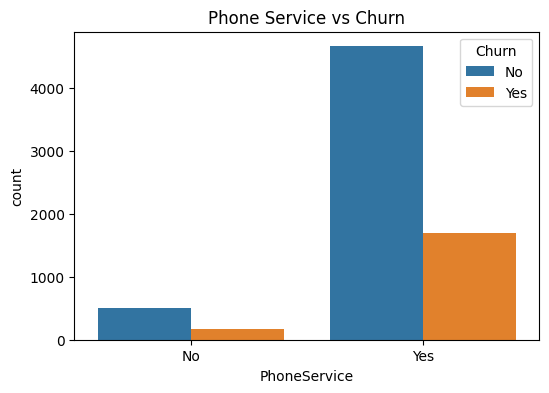

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='PhoneService', hue='Churn', data=df)
plt.title("Phone Service vs Churn")
plt.show()

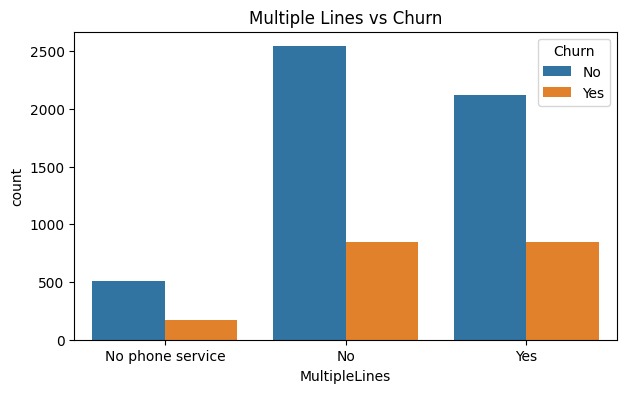

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='MultipleLines', hue='Churn', data=df)
plt.title("Multiple Lines vs Churn")
plt.show()

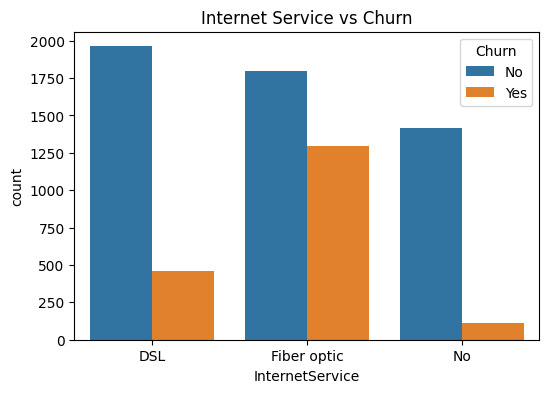

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

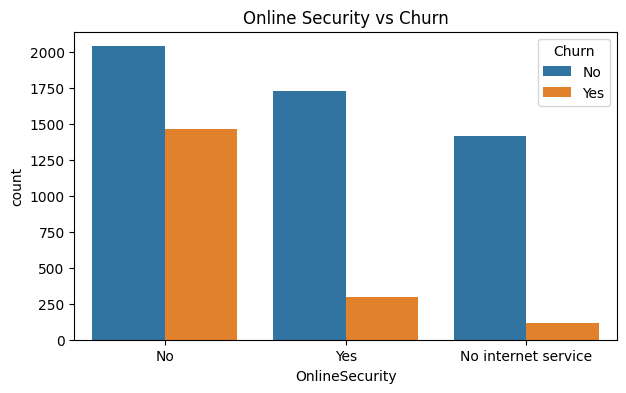

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title("Online Security vs Churn")
plt.show()

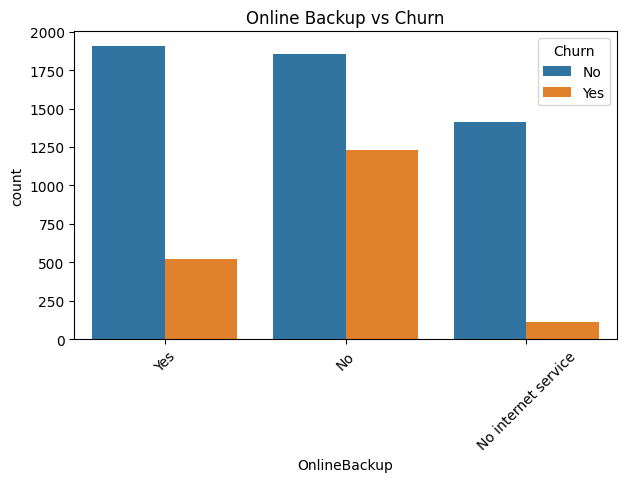

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='OnlineBackup', hue='Churn', data=df)
plt.title("Online Backup vs Churn")
plt.show()

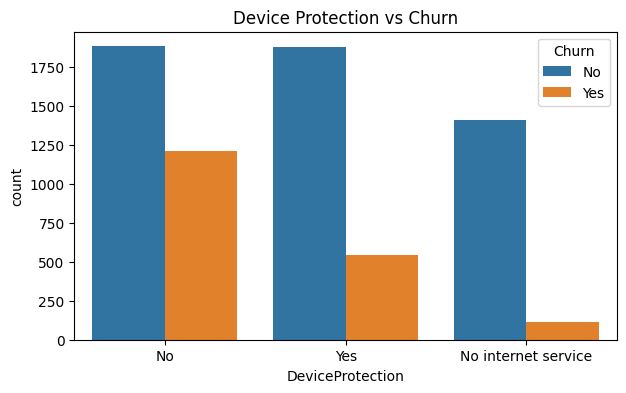

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='DeviceProtection', hue='Churn', data=df)
plt.title("Device Protection vs Churn")
plt.show()

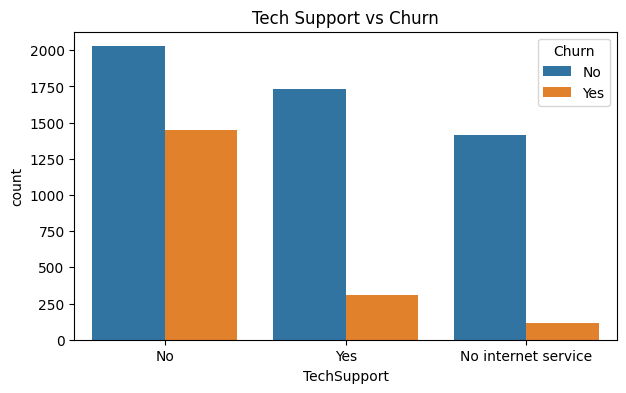

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Tech Support vs Churn")
plt.show()

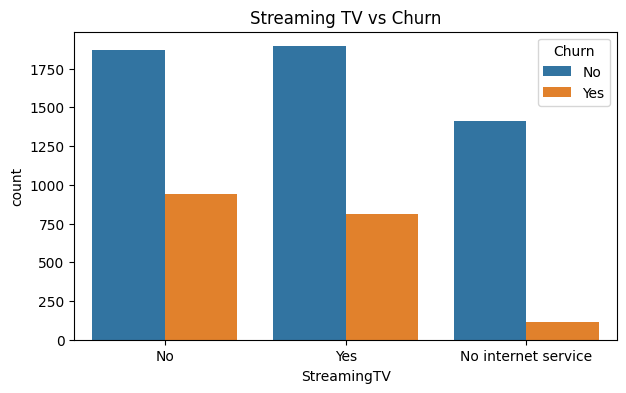

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='StreamingTV', hue='Churn', data=df)
plt.title("Streaming TV vs Churn")
plt.show()

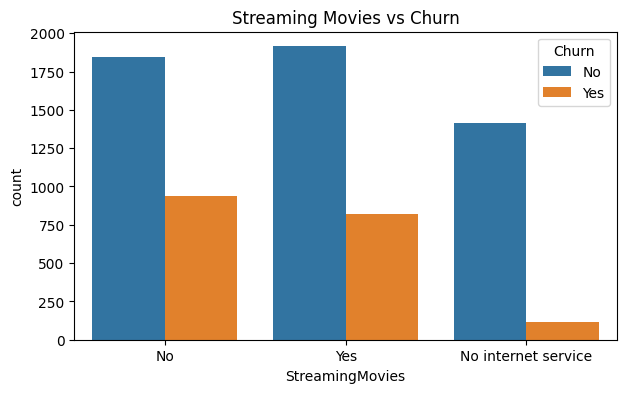

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='StreamingMovies', hue='Churn', data=df)
plt.title("Streaming Movies vs Churn")
plt.show()

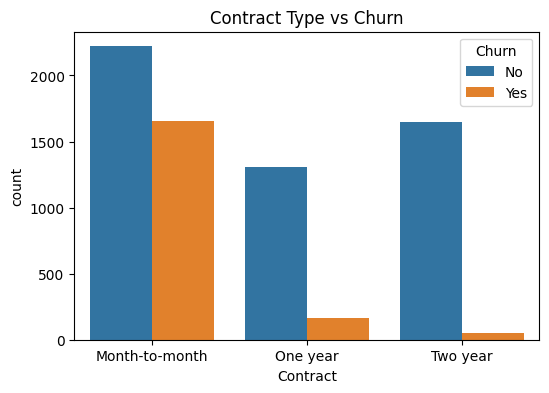

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

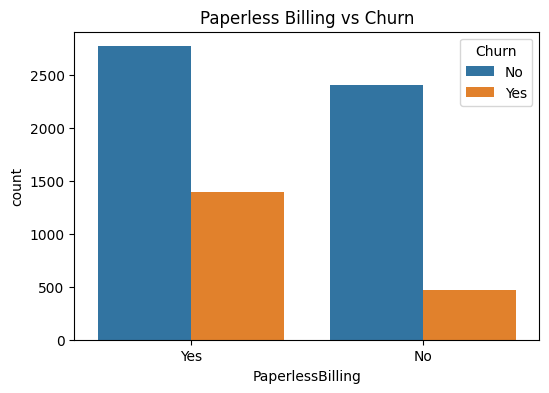

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title("Paperless Billing vs Churn")
plt.show()

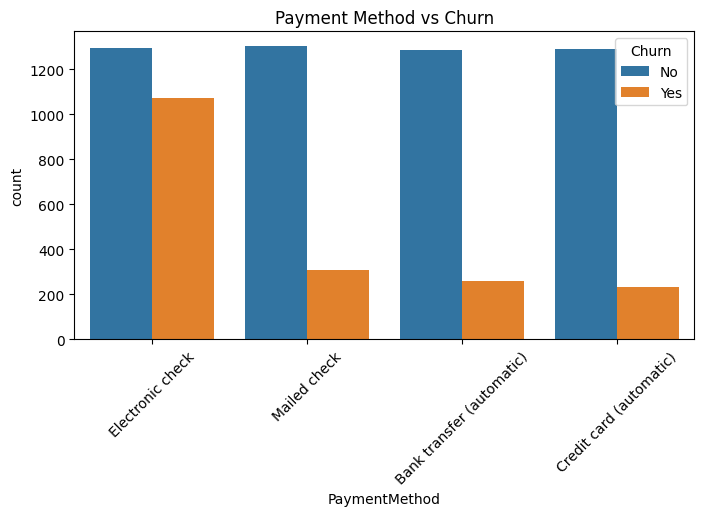

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

#Churn vs Numerical Features

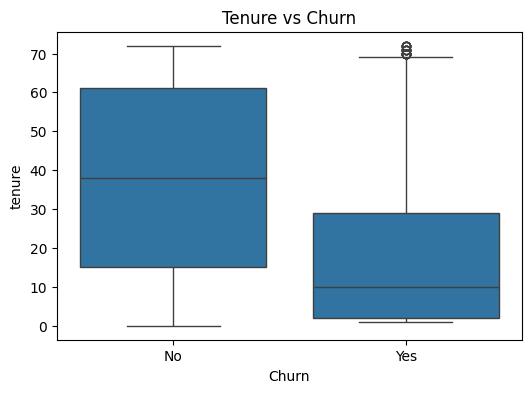

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

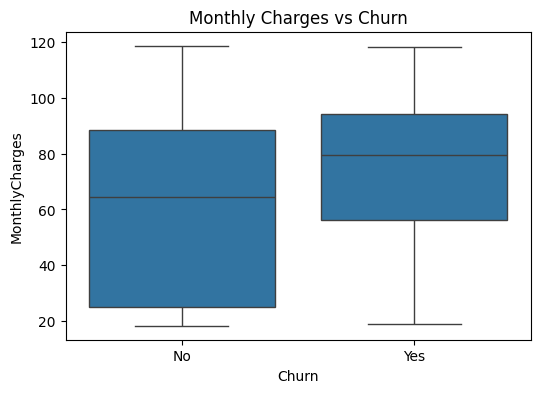

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

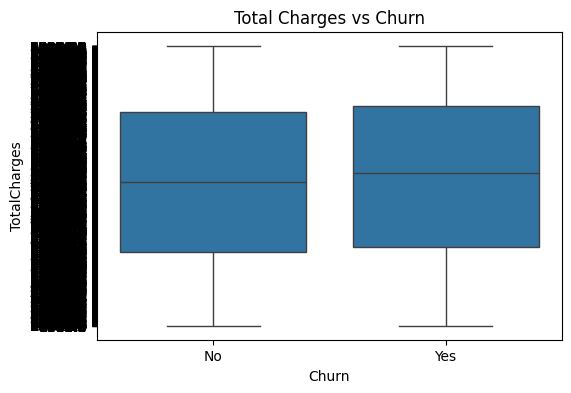

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn")
plt.show()

#8. Generate Correlation Heatmap

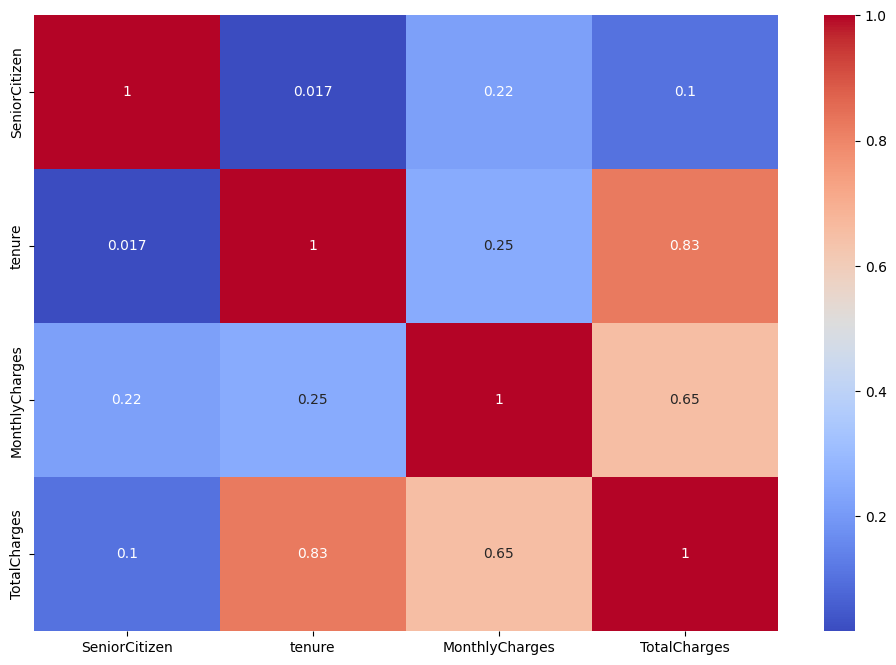

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 9. Detect and Handle Outliers

In [ ]:
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3 - Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df=df[(df[col]>=lower)&(df[col]<=upper)]

# 10. Apply Encoding

● Label Encoding

● One-Hot Encoding

In [ ]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

One Hot encoding

In [ ]:
onehot_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [ ]:
df = pd.get_dummies(df,
                    columns=onehot_cols,
                    drop_first=True)

#11 Apply Scaling

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df.drop("Churn", axis=1))

#12 Separate Features & Target

In [ ]:
X = X_scaled
y = df["Churn"]

#13 Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#14 Handle Imbalanced Data (SMOTE)

In [ ]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [3603 3603]


#15 Train Classification Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
models={
    "Logistic Regression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "SVC":SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    results[name] = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]

    print("\n", name)
    print(confusion_matrix(y_test, y_pred))


 Logistic Regression
[[679 226]
 [ 61 214]]

 KNN
[[603 302]
 [ 80 195]]

 Decision Tree
[[705 200]
 [125 150]]

 Random Forest
[[767 138]
 [119 156]]

 SVC
[[711 194]
 [ 76 199]]

 Gradient Boosting
[[734 171]
 [ 83 192]]

 XGBoost
[[780 125]
 [120 155]]


#17. Apply Hyperparameter Tuning
GridSearchCV (Random Forest)

In [ ]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid,
                    cv=5)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
random = RandomizedSearchCV(RandomForestClassifier(),param_distributions=param_grid,n_iter=5,cv=5,random_state=42,n_jobs=-1)

In [ ]:
random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


# 18 Compare Model Performance

In [ ]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
).T

print(results_df)

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.756780   0.486364  0.778182  0.598601  0.850959
KNN                  0.676271   0.392354  0.709091  0.505181  0.744719
Decision Tree        0.724576   0.428571  0.545455  0.480000  0.661226
Random Forest        0.782203   0.530612  0.567273  0.548330  0.821949
SVC                  0.771186   0.506361  0.723636  0.595808  0.829603
Gradient Boosting    0.784746   0.528926  0.698182  0.601881  0.852048
XGBoost              0.792373   0.553571  0.563636  0.558559  0.821657


# 19 Select Best Model

In [ ]:
best_model = results_df["F1 Score"].idxmax()

print("Best Model:", best_model)

Best Model: Gradient Boosting


# 20 Insights — Customer Churn Prediction

Following important factors were identified as major reasons for customer churn:

1️. High Monthly Charges

Customers paying higher monthly charges are more likely to leave the company. High pricing increases customer dissatisfaction and encourages customers to switch to competitors.

2️.  Month-to-Month Contract Customers

Customers with month-to-month contracts show the highest churn rate because they are not bound by long-term agreements and can easily discontinue the service.

3️.  Lack of Technical Support

Customers who do not receive technical support or assistance tend to churn more frequently. Poor service experience directly impacts customer retention.

4️.  Short Customer Tenure

New customers or customers with shorter tenure have a higher probability of leaving. This indicates that early customer engagement and satisfaction are critical.

5️.  Internet Service Type

Customers using high-speed or premium internet services (e.g., fiber optic) often show higher churn due to higher pricing or service expectations.

6️.  Paperless Billing & Payment Methods

Certain payment methods, especially electronic check users, demonstrate higher churn behavior compared to automatic payment users.